# XBTorch::Example 10:Custom Device Models

## Introduction

In this example, we will see how to construct device models from custom device data. We will use XBTorch's tabular device models for this purpose. Using this custom device model, we will also see how to train a simple neural network. Once a custom model has been created, it can be used with other XBTorch features such as hardware-aware training or inference.

## Getting Started

Let's import necessary dependencies.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from xbtorch.devices import TabularCompactFeFETKriging, TabularAnalyticalReal, TabularDevice
from xbtorch.devices.utils import synthesize_G_dG_dataset, get_kriging_profiles, construct_cdf

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


Let's write a function for visualizing a tabular device model. A tabular device model is simply a 2-dimensional array of cumulative distribution functions mapping from initial conductance, G, to change in conductance per applied voltage pulse (ΔG / pulse). All three of these components, namely the G and ΔG axes and the CDF array are initialized within XBTorch device models and can be accessed directly.

In [2]:
def plot_jumptable(G, dG, cdf, title):
    fig, ax = plt.subplots(1, 1)
    ax.set_box_aspect(1)
    
    X, Y = np.meshgrid(G, dG)
    
    # cdf needs to be transposed since we require plotting dG against G
    Z = np.transpose(cdf).reshape(len(dG), len(G))
    im = ax.pcolormesh(X, Y, Z, cmap='RdYlBu')
    ax.ticklabel_format(axis="both")
    ax.set_ylabel('ΔG / pulse (S)')
    ax.set_xlabel('G (S)')

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_title('CDF')
    
    plt.title(title)

## Visualizing Tabular Presets

Let's visualize a few example device model presets with XBTorch provides. 

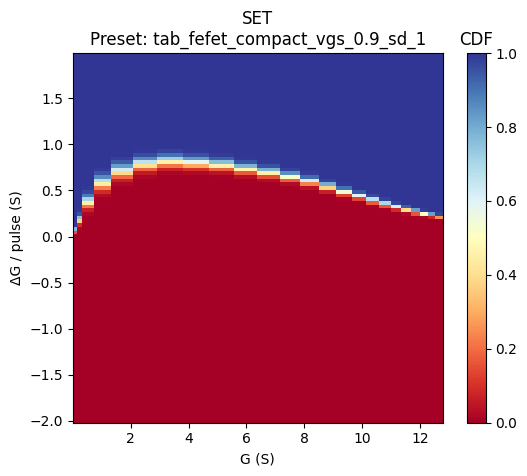

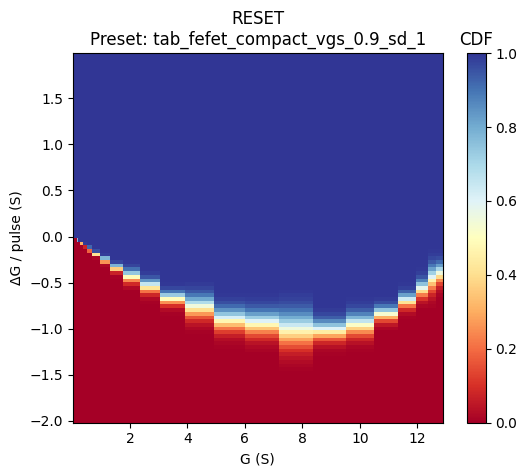

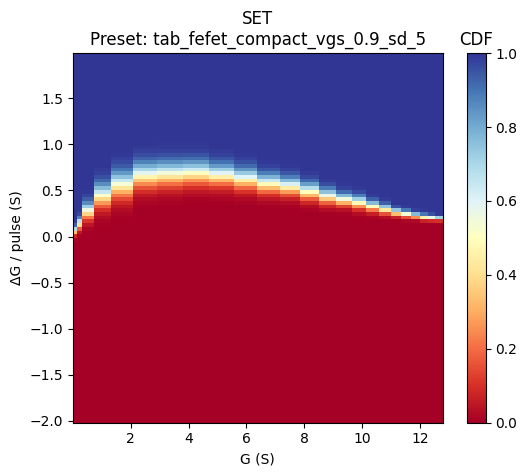

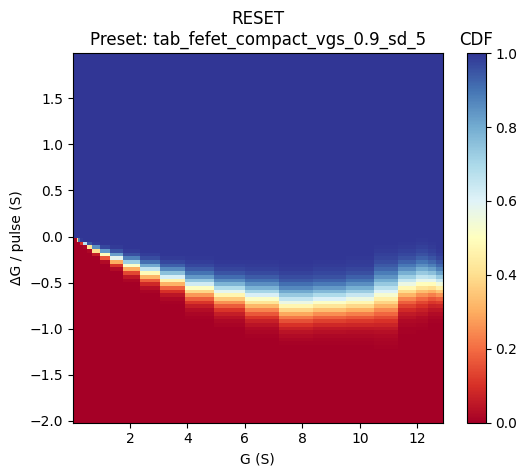

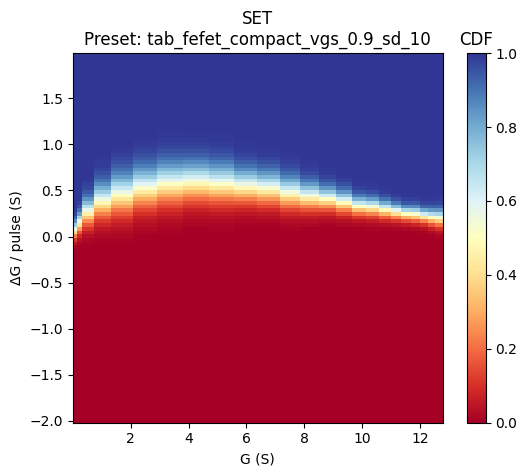

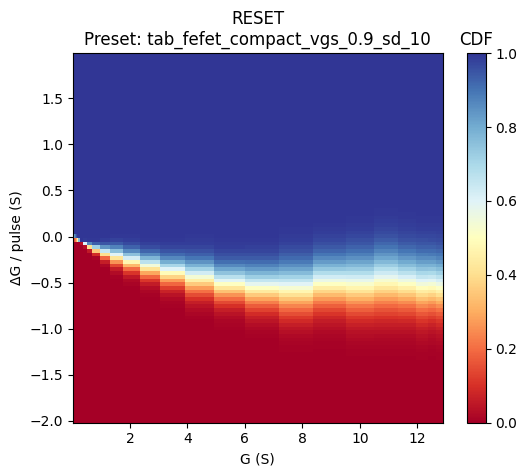

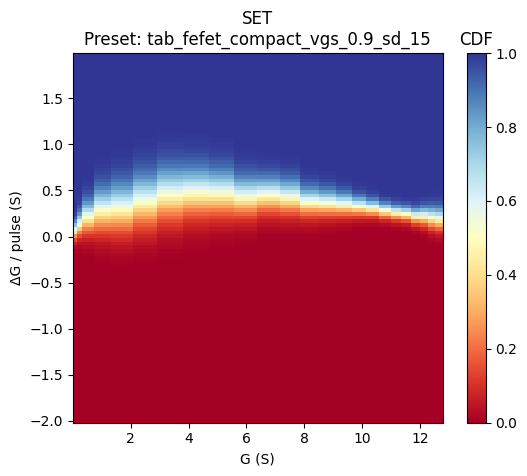

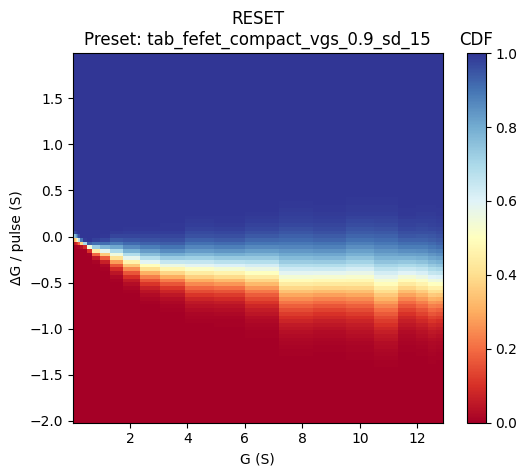

In [3]:
sds = [1, 5, 10, 15]

for sd in sds:
    xb_device_model = f"tab_fefet_compact_vgs_0.9_sd_{sd}"
    xb_device = TabularCompactFeFETKriging(xb_device_model)

    jump_table = xb_device._device
    
    reset_G = jump_table.reset_G
    reset_dG = jump_table.reset_dG
    reset_cdf = jump_table.reset_cdf
    
    set_G = jump_table.set_G
    set_dG = jump_table.set_dG
    set_cdf = jump_table.set_cdf

    plot_jumptable(set_G, set_dG, set_cdf, title=f"SET\nPreset: {xb_device_model}")
    plot_jumptable(reset_G, reset_dG, reset_cdf, title=f"RESET\nPreset: {xb_device_model}")

## Custom Device Model

We have already seen how these existing presets could be used for realizing neural network inference or training within XBTorch.

Let's now dive into creating a device model from custom device data.

For the sake of completeness, let's synthesize our custom device dataset based on XBTorch features that we previously explored Example 02. If we had (G, ΔG / pulse) measurements from elsewhere, we would simply skip this synthesis step and load that data directly. As long as data is preset for SET and RESET operations in the (G, ΔG / pulse) format, it can be used!

In [4]:
num_points = 3000

device = TabularAnalyticalReal()

set_dataset = synthesize_G_dG_dataset(device, set=True, num_points=num_points, disable_filtering=False)
reset_dataset = synthesize_G_dG_dataset(device, set=False, num_points=num_points, disable_filtering=False)

All we need to do now is generate the jump table models. XBTorch provides an implementation for using Kriging-based interpolation from [1] to create these jump table models. 

The implementation is available in the `devices.utils` module.  View the full API documentation for further details. 

In [5]:
# First for SET
xt, yt = set_dataset[:, 0], set_dataset[:, 1]
set_G_axis, set_dG_axis, set_mean_profile, set_std_profile = get_kriging_profiles(xt, yt, axis_size=100)

___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 3000
   
___________________________________________________________________________
   
 Training
   
   Training ...


/home/zaza/NeuroTorch_paper/xbtorch/env/lib/python3.10/site-packages/smt/surrogate_models/krg_based.py:2485: UserWarning: TNC not available yet for noise handling. Switching to Cobyla
  warnings.warn(


   Training - done. Time (sec): 106.2927096
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 100
   
   Predicting ...
   Predicting - done. Time (sec):  0.0047536
   
   Prediction time/pt. (sec) :  0.0000475
   


In [6]:
# Repeat now for RESET
xt, yt = reset_dataset[:, 0], reset_dataset[:, 1]
reset_G_axis, reset_dG_axis, reset_mean_profile, reset_std_profile = get_kriging_profiles(xt, yt, axis_size=100)

___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 3000
   
___________________________________________________________________________
   
 Training
   
   Training ...


/home/zaza/NeuroTorch_paper/xbtorch/env/lib/python3.10/site-packages/smt/surrogate_models/krg_based.py:2485: UserWarning: TNC not available yet for noise handling. Switching to Cobyla
  warnings.warn(


   Training - done. Time (sec): 96.5555000
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 100
   
   Predicting ...
   Predicting - done. Time (sec):  0.0041018
   
   Prediction time/pt. (sec) :  0.0000410
   


Let's visualize our mean and standard deviation profiles so far.

In [7]:
# shift to XBTorch
def plot_mean_std_profiles(G, dG, G_axis, mean_profile, std_profile):

    _, axs = plt.subplots(1)
    # Plot original dataset (from which we construct our jump table model)
    axs.plot(G, dG, "o", alpha=0.1)
    # Plot the mean profile
    axs.plot(G_axis, mean_profile)
    # Plot the std profile
    axs.fill_between(
        G_axis,
        np.ravel(mean_profile - std_profile),
        np.ravel(mean_profile + std_profile),
        color="lightgrey",
    )
    axs.set_xlabel("Conductance (S)")
    axs.set_ylabel("ΔG / pulse (S)")
    axs.legend(
        ["Training data", "Prediction", "Standard Deviation"],
        loc="lower right",
    )

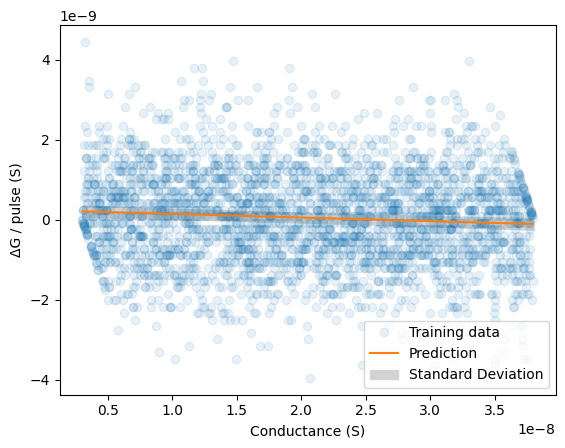

In [8]:
plot_mean_std_profiles(set_dataset[:, 0], set_dataset[:, 1], set_G_axis, set_mean_profile, set_std_profile)

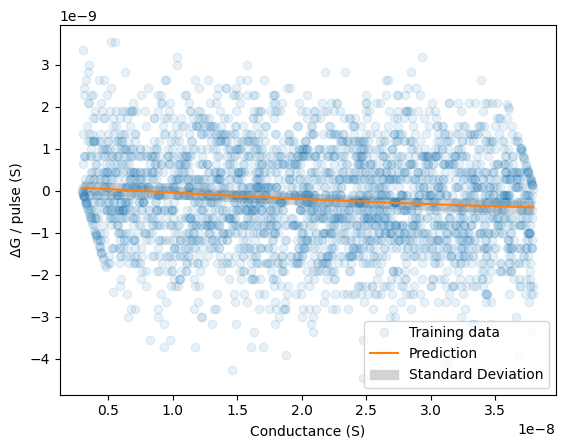

In [9]:
plot_mean_std_profiles(reset_dataset[:, 0], reset_dataset[:, 1], reset_G_axis, reset_mean_profile, reset_std_profile)

The only thing remaining for our jump table model is now the CDF array.

In [10]:
set_cdf = construct_cdf(set_G_axis, set_dG_axis, set_mean_profile, set_std_profile)
reset_cdf = construct_cdf(reset_G_axis, reset_dG_axis, reset_mean_profile, reset_std_profile)

## Save Custom Model 

We recommend saving a custom model as shown below. This ensures that the entire model creation pipeline doesn't have to be re-run for later experiments.

In [11]:
name = "custom_example_model"

np.savetxt(f'checkpoints/{name}_set_axis_level_G.txt', set_G_axis)
np.savetxt(f'checkpoints/{name}_set_axis_level_dG.txt', set_dG_axis)
np.savetxt(f'checkpoints/{name}_set_cdf.txt', set_cdf)

np.savetxt(f'checkpoints/{name}_reset_axis_level_G.txt', reset_G_axis)
np.savetxt(f'checkpoints/{name}_reset_axis_level_dG.txt', reset_dG_axis)
np.savetxt(f'checkpoints/{name}_reset_cdf.txt', reset_cdf)

## Using Custom Model

Now that we have generated our custom model, we can load and visualise it like other models or presets.

In [12]:
custom_device_model = TabularDevice(
    reset_g=f'checkpoints/{name}_reset_axis_level_G.txt',
    reset_dg=f'checkpoints/{name}_reset_axis_level_dG.txt',
    reset_cdf=f'checkpoints/{name}_reset_cdf.txt',
    set_g=f'checkpoints/{name}_set_axis_level_G.txt',
    set_dg=f'checkpoints/{name}_set_axis_level_dG.txt',
    set_cdf=f'checkpoints/{name}_set_cdf.txt',
    max_level=500 # hyperparameter
)

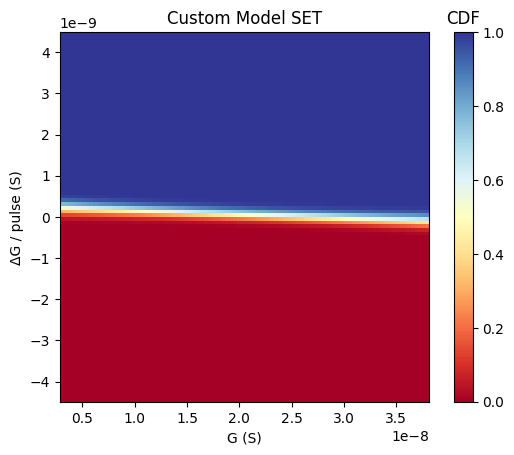

In [13]:
plot_jumptable(custom_device_model.set_G, custom_device_model.set_dG, custom_device_model.set_cdf, title=f"Custom Model SET")

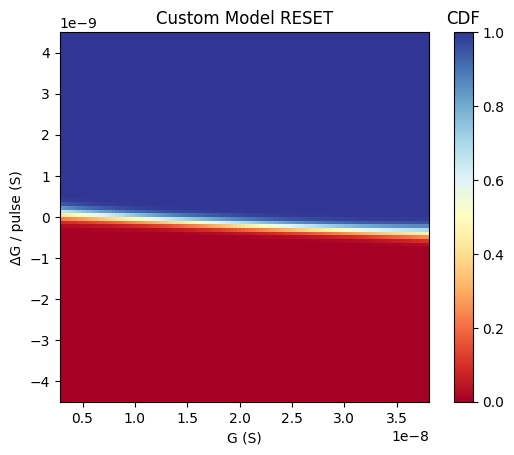

In [14]:
plot_jumptable(custom_device_model.reset_G, custom_device_model.reset_dG, custom_device_model.reset_cdf, title=f"Custom Model RESET")

The custom model can now be used for any investigation that XBTorch supports (that we've seen in previous examples), such as hardware-aware training, hardware-aware inference, and even gradient decomposition methods! All one needs to ensure is to provide the custom device model when initializing XBTorch (given by the `device_type` parameter).

## Conclusion

We have seen how to create an XBTorch-compatible device model using custom device measurements. Once created, a custom device model can be utilized just like other pre-provided device presets for high-level applications and investigations. This includes all examples we have seen so far where a device model is specified and utilized.

## References
1. Hossen, I., Anders, M. A., Wang, L., & Adam, G. C. (2022). Data-driven RRAM device models using Kriging interpolation. Scientific Reports, 12(1), 5963.